# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

In [1]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader, Subset

from model.helpers import collate_fn

# Same dataset setup style as train.py
root = "/Users/nikan/Desktop/PersonalProjects/Notarius/datasets"
train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=True)

small_train_ds = Subset(train_ds, range(200))

# Apply collate function through DataLoader
train_loader = DataLoader(
    small_train_ds,
    batch_size=12,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)


/Users/nikan/Desktop/PersonalProjects/Notarius/notariusvenv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/Users/nikan/Desktop/PersonalProjects/Notarius/notariusvenv/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/nikan/Desktop/PersonalProjects/Notarius/notariusvenv/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder ins

Batch size: 12
Input lengths (first 5): [542, 1864, 188, 1436, 2307]
Target lengths (first 5): [76, 286, 5, 194, 375]
Original audio length (sample 10): 1244 frames


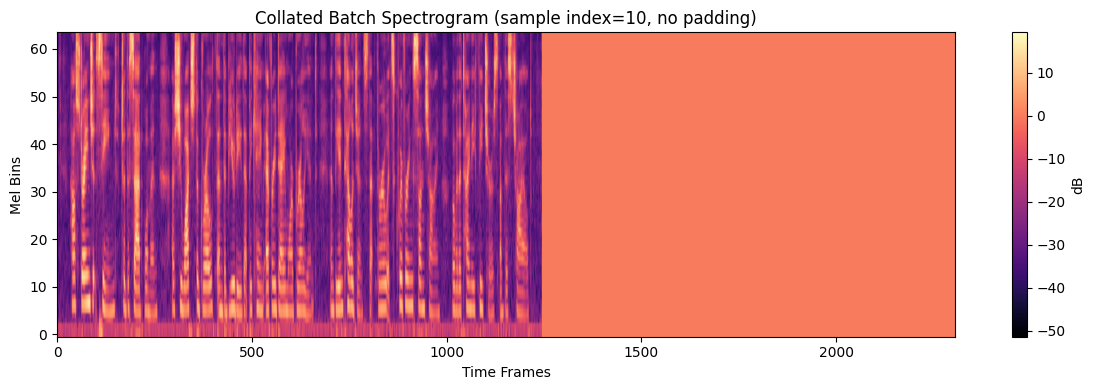

In [2]:
# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (n_mels, time)

# Crop to true (unpadded) length so padding is not shown
original_length = int(input_lengths[idx].item())
spec_no_pad = spec[:]
print(f"Original audio length (sample {idx}): {original_length} frames")

plt.figure(figsize=(12, 4))
plt.imshow(spec_no_pad, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx}, no padding)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

In [3]:
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

sample_idx = idx if 0 <= idx < len(spectrogram_batch) else 0
input_len = int(input_lengths[sample_idx].item())
target_len = int(target_lengths[sample_idx].item())

# Show the end of the spectrogram to inspect zero-padding
tail_frames = 10
print(f"\nSpectrogram tail (first 5 mel bins x last {tail_frames} frames):")
print(spectrogram_batch[sample_idx, :5, -tail_frames:])

# How many mel bins are non-zero in each of the last frames
print(f"\nNon-zero mel-bin count per last {tail_frames} frames:")
print((spectrogram_batch[sample_idx, :, -tail_frames:] != 0).sum(dim=0))

print(f"Sample index: {sample_idx}")
print(f"Spectrogram shape (padded): {tuple(spectrogram_batch[sample_idx].shape)}")
print(f"Input length (true frames): {input_len}")
print(f"Target length (true tokens): {target_len}")

print("\nTarget tokens (unpadded):")
print(targets_batch[sample_idx, :target_len])

print("\nSpectrogram snippet (first 5 mel bins x first 10 frames):")
print(spectrogram_batch[sample_idx, :5, :10])


Spectrogram tail (first 5 mel bins x last 10 frames):
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Non-zero mel-bin count per last 10 frames:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Sample index: 10
Spectrogram shape (padded): (64, 2307)
Input length (true frames): 1244
Target length (true tokens): 208

Target tokens (unpadded):
tensor([ 7, 14, 22, 26, 18, 19, 17,  0, 13,  6,  4, 26,  8, 19, 26, 18,  4,  4,
        12,  4,  3, 26, 19, 14, 26, 19,  7,  4, 26, 18,  0,  3, 26, 22, 14, 12,
         0, 13, 26,  0, 18, 26, 18,  7,  4, 26, 22,  0, 19,  2,  7,  4,  3, 26,
        19,  7,  4, 26,  6, 17, 14, 22, 19,  7, 26,  0, 13,  3, 26, 19,  7,  4,
        26,  1,  4,  0, 20, 19, 24, 26, 19,  7,  0, 19, 26,  1,  4,  2,  0, 12,
         4, 26,  4, 21,  4, 17, 24, 26,  3,  0, 24, 26, 12, 14